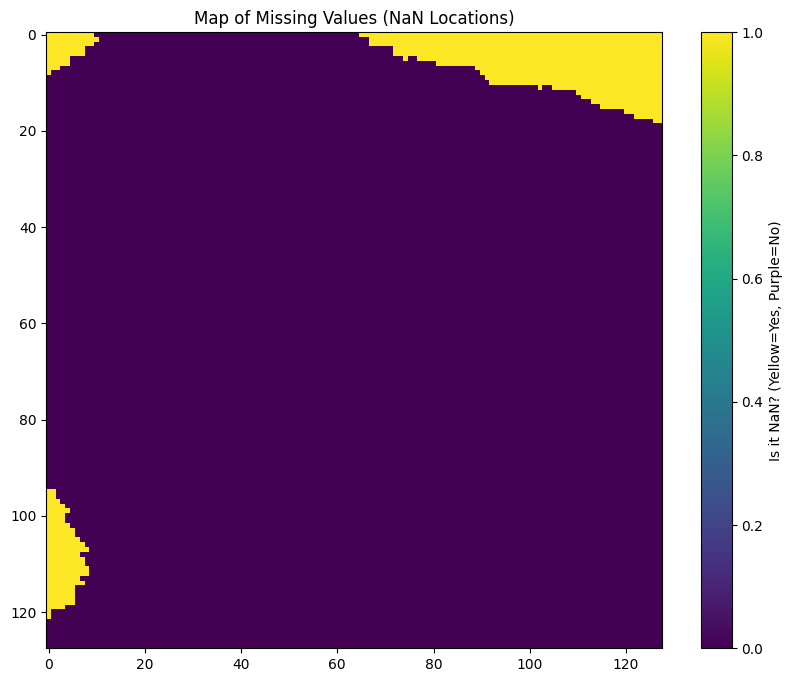

In [36]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

# 1. 读取数据
ds = xr.open_dataset('./data/mini_dataset_new.nc')

# 2. 挑一个肯定有问题的变量，比如 NDVI
# 取第0天的数据
sample_data = ds['ndvi'].isel(time=10) #取变量ndvi,fwi,max_wind_speed,max_t2m

# 3. 制作一张“侦探图”
# 如果是 NaN，就是 True (黄色/亮色)
# 如果有值，就是 False (紫色/暗色)
nan_mask = np.isnan(sample_data.values)

# 4. 画图
plt.figure(figsize=(10, 8))
plt.imshow(nan_mask, cmap='viridis')
plt.colorbar(label='Is it NaN? (Yellow=Yes, Purple=No)')
plt.title("Map of Missing Values (NaN Locations)")
plt.show()

In [8]:
import xarray as xr

ds = xr.open_dataset('./data/mini_dataset.nc')

print("=== 变量维度检查 ===")
for var in ['ndvi', 'max_t2m', 'burned_areas']:
    print(f"变量 [{var}] 的维度: {ds[var].dims}")
    print(f"变量 [{var}] 的坐标: {list(ds[var].coords)}")
    print("-" * 20)

=== 变量维度检查 ===
变量 [ndvi] 的维度: ('time', 'y', 'x')
变量 [ndvi] 的坐标: ['time', 'x', 'y', 'band', 'spatial_ref']
--------------------
变量 [max_t2m] 的维度: ('time', 'y', 'x')
变量 [max_t2m] 的坐标: ['time', 'x', 'y', 'band', 'spatial_ref']
--------------------
变量 [burned_areas] 的维度: ('time', 'y', 'x')
变量 [burned_areas] 的坐标: ['time', 'x', 'y', 'band', 'spatial_ref']
--------------------


In [3]:
import xarray as xr
import numpy as np

input_file = './data/dataset_greece.nc'
output_file = './data/dataset_allyear.nc'  # 改个名字，叫 year

print("🚀 正在制作【全年】玩具数据集...")

# 1. 读取
ds = xr.open_dataset(input_file)

# 2. 核心切片：时间改成了 "2021" (代表2021全年)
# 空间范围我帮你选了一个陆地比较多的区域 (x:300-428, y:500-628)
# 也就是 128x128 大小
print("正在切片 (2021全年 + 纯陆地区域)...")
mini_ds = ds.isel(x=slice(360, 488), y=slice(500, 628))

# 3. 修复数据 (就是你刚才问的那行代码)
# 先插值修缝隙，再把大海填成0
print("正在清洗 NaN...")
mini_ds = mini_ds.interpolate_na(dim='x', method='nearest').fillna(0)

# 4. 保存
print(f"正在保存到 {output_file} ...")
# 启用压缩，文件会更小
encoding = {k: {'zlib': True, 'complevel': 5} for k in mini_ds.data_vars}
mini_ds.to_netcdf(output_file, encoding=encoding)

print("-" * 30)
print(f"✅ 完成！文件已保存为 {output_file}")
print("这个数据集包含了春夏秋冬，非常适合训练模型！")

🚀 正在制作【全年】玩具数据集...
正在切片 (2021全年 + 纯陆地区域)...
正在清洗 NaN...
正在保存到 ./data/dataset_allyear.nc ...
------------------------------
✅ 完成！文件已保存为 ./data/dataset_allyear.nc
这个数据集包含了春夏秋冬，非常适合训练模型！


In [2]:
import xarray as xr
import numpy as np
import tqdm
import os

# ================= 配置区 =================
BIG_FILE_PATH = "/root/autodl-tmp/Graduation_Paper/data/dataset_greece.nc"
INDEX_SAVE_PATH = "./fire_indices.npy"
FIRE_VAR = "burned_areas"
PATCH_SIZE = 128
HALF_SIZE = PATCH_SIZE // 2
MAX_SAMPLES_PER_DAY = 10 
BATCH_SIZE = 500  # ✨ 关键：一次读 500 天到内存处理
# =========================================

def scan_fire_fast():
    print(f"🚀 正在打开大文件: {BIG_FILE_PATH}")
    
    # 1. 这里的 chunks={} 设为空字典，让 xarray 使用文件原本的存储块结构，最快！
    # 或者直接不写 chunks 参数也可以
    ds = xr.open_dataset(BIG_FILE_PATH, chunks={})
    
    total_days = ds.sizes['time']
    height = ds.sizes['y']
    width = ds.sizes['x']
    print(f"📏 地图大小: {height}x{width}, 总天数: {total_days}")
    
    valid_indices = []
    
    # 从第10天开始
    start_day = 10
    
    # ✨ 2. 批量处理循环 (Batch Processing)
    # 每次处理 BATCH_SIZE 天，而不是 1 天
    for t_start in tqdm.tqdm(range(start_day, total_days, BATCH_SIZE), desc="🔥 高速扫描中"):
        
        t_end = min(t_start + BATCH_SIZE, total_days)
        
        # --- 核心优化 ---
        # 一次性把这 500 天的火灾数据读入内存 (RAM)
        # 500 * 1000 * 1000 * 4 bytes ≈ 2GB 内存，32G 显存/内存绰绰有余
        try:
            batch_fire = ds[FIRE_VAR].isel(time=slice(t_start, t_end)).values
        except Exception as e:
            print(f"读取 Batch {t_start}-{t_end} 失败: {e}")
            continue
            
        # 此时 batch_fire 是一个 numpy 数组，形状 (500, H, W)
        # 我们在内存里做运算，速度极快
        
        # 找到这个 Batch 里所有大于 0 的位置
        # batch_indices 返回三个数组: (相对时间t, y, x)
        # 注意：这里的 t 是相对于 batch 的 (0~499)
        batch_ts, batch_ys, batch_xs = np.where(batch_fire > 0)
        
        # 如果这个 Batch 里完全没火，直接下一个
        if len(batch_ts) == 0:
            continue
            
        # 为了防止某些天火太大导致样本爆炸，我们需要按“天”来分组处理
        # 找出这个 batch 里有哪些天着火了
        unique_days = np.unique(batch_ts)
        
        for rel_day in unique_days:
            # 还原真实时间索引
            real_day = t_start + rel_day
            
            # 找到这一天所有的火点索引
            # mask 是个布尔数组
            mask = (batch_ts == rel_day)
            ys = batch_ys[mask]
            xs = batch_xs[mask]
            
            num_fires = len(ys)
            
            # 随机采样
            if num_fires > MAX_SAMPLES_PER_DAY:
                choices = np.random.choice(num_fires, MAX_SAMPLES_PER_DAY, replace=False)
                selected_y = ys[choices]
                selected_x = xs[choices]
            else:
                selected_y = ys
                selected_x = xs
            
            # 存入结果
            for y, x in zip(selected_y, selected_x):
                # 边界检查
                if (y - HALF_SIZE >= 0) and (y + HALF_SIZE < height) and \
                   (x - HALF_SIZE >= 0) and (x + HALF_SIZE < width):
                    valid_indices.append([real_day, y, x])

    # 保存
    all_indices = np.array(valid_indices)
    np.save(INDEX_SAVE_PATH, all_indices)
    print(f"\n✅ 扫描完成！共找到 {len(all_indices)} 个正样本坐标。")
    print(f"💾 坐标已保存至: {INDEX_SAVE_PATH}")

scan_fire_fast()

🚀 正在打开大文件: /root/autodl-tmp/Graduation_Paper/data/dataset_greece.nc
📏 地图大小: 983x1253, 总天数: 4560


🔥 高速扫描中: 100%|██████████| 10/10 [20:48<00:00, 124.86s/it]


✅ 扫描完成！共找到 5039 个正样本坐标。
💾 坐标已保存至: ./fire_indices.npy


In [1]:
import xarray as xr
import numpy as np
import tqdm
import os
import pandas as pd

# ================= 配置区 =================
BIG_FILE_PATH = "/root/autodl-tmp/Graduation_Paper/data/dataset_greece.nc"
INDEX_FILE_PATH = "./fire_indices.npy"
OUTPUT_NC_PATH = "./data/balanced_train_data_2000.nc"

SEQ_LEN = 10      # 过去10天
PATCH_SIZE = 128
HALF_SIZE = PATCH_SIZE // 2

FEATURE_NAMES = [
    'burned_areas', 'ndvi', 'fwi', 
    'max_t2m', 'max_wind_speed', 
    'CLC_2018_6', 'CLC_2018_7', 'CLC_2018_8'
]
# =========================================

def extract_surgical():
    if not os.path.exists(INDEX_FILE_PATH):
        print("❌ 找不到索引文件！")
        return

    print("📖 正在加载索引文件...")
    indices = np.load(INDEX_FILE_PATH)
    
    # 1. 筛选逻辑
    df = pd.DataFrame(indices, columns=['t', 'y', 'x'])
    df = df.sort_values('t') # 稍微排个序，让硬盘磁头少跳一点

    # ✂️ 只取 500 个用于快速验证
    if len(df) > 2000:
        print(f"✂️ 正在随机抽取 5000 个样本...")
        df = df.sample(n=2000, random_state=42).sort_values('t')
    
    total_samples = len(df)
    print(f"🔥 准备提取 {total_samples} 个样本 (外科手术模式)...")

    # 2. 预分配数组
    num_vars = len(FEATURE_NAMES)
    all_data = np.zeros((total_samples, SEQ_LEN, num_vars, PATCH_SIZE, PATCH_SIZE), dtype=np.float32)

    # 3. 打开大文件 (不加载数据，只建立连接)
    # chunks=None 或 {} 表示使用文件原生的分块方式
    ds = xr.open_dataset(BIG_FILE_PATH, chunks={})
    
    # 4. 逐个提取 (Surgical Extraction)
    # 因为只需要读极小的数据量 (128x128)，所以循环 500 次会非常快
    
    print("🚀 开始极速切割...")
    success_count = 0
    
    # 使用 tqdm 显示进度
    for i, (_, row) in tqdm.tqdm(enumerate(df.iterrows()), total=total_samples):
        t_center = int(row['t'])
        y_center = int(row['y'])
        x_center = int(row['x'])
        
        # 计算切片范围
        t_start = t_center - SEQ_LEN + 1
        t_end = t_center + 1 # xarray slice是包含结尾的，但isel如果不含需要注意
        
        y_min = y_center - HALF_SIZE
        y_max = y_center + HALF_SIZE
        x_min = x_center - HALF_SIZE
        x_max = x_center + HALF_SIZE
        
        try:
            # --- 核心：只读取这一小块 ---
            # 我们直接在硬盘上定位到这个小方块，只读这几MB数据
            patch_xr = ds[FEATURE_NAMES].isel(
                time=slice(t_start, t_end),
                y=slice(y_min, y_max),
                x=slice(x_min, x_max)
            )
            
            # 转 Numpy (这一步才会触发硬盘 I/O)
            patch_val = patch_xr.to_array(dim='variable').values
            # 形状: (Vars, Time, H, W) -> 转置为 (Time, Vars, H, W)
            patch_val = patch_val.transpose(1, 0, 2, 3)
            
            # 填入大数组
            all_data[i] = patch_val
            success_count += 1
            
        except Exception as e:
            print(f"⚠️ 样本 {i} 读取失败: {e}")
            continue

    print(f"💾 正在保存 {success_count} 个样本...")
    
    new_ds = xr.Dataset(
        {
            "data": (["sample", "time", "variable", "y", "x"], all_data[:success_count])
        },
        coords={
            "sample": np.arange(success_count),
            "variable": FEATURE_NAMES,
        }
    )
    
    # 压缩保存
    encoding = {'data': {'zlib': True, 'complevel': 5}}
    new_ds.to_netcdf(OUTPUT_NC_PATH, engine='h5netcdf', encoding=encoding)
    
    print(f"✅ 搞定！文件已保存至: {OUTPUT_NC_PATH}")

extract_surgical()

📖 正在加载索引文件...
✂️ 正在随机抽取 5000 个样本...
🔥 准备提取 2000 个样本 (外科手术模式)...
🚀 开始极速切割...


 11%|█▏        | 226/2000 [09:20<1:13:21,  2.48s/it]


KeyboardInterrupt: 